# Trabajo Práctico 2 / TS2 | Romero Marchione, Luz | 9/9/26

En este trabajo se simulará el comportamiento de un ADC al digitalizar una senoidal contaminada con ruido analógico, analizando cómo varía la salida al cambiar la cantidad de bits $B$ y la relación: $k_n=\frac{P_n}{P_q}$

Se estudiarán las diferencias en el dominio temporal y frecuencial, y especialmente el comportamiento del ruido de cuantización mediante su secuencia, autocorrelación y espectro, para observar cuándo se comporta como ruido aproximadamente incorrelado y blanco.

También se comparará la relación entre la resolución del ADC y el SNR.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Fundamentos teóricos</h2>
</div>

### Conversión analógico-digital y cuantización

Un **conversor analógico-digital (ADC)** transforma una señal muestreada en una secuencia cuyos valores de amplitud pertenecen a un conjunto finito de niveles. Para un ADC de $B$ bits existen $2^B$ niveles y, si el rango total de entrada es $V_{FS}$, el paso de cuantización queda definido por

$$
q=\frac{V_{FS}}{2^B}
$$

En este trabajo el ADC opera entre $-V_R$ y $+V_R$, por lo que $V_{FS}=2V_R$. La cuantización se realizará mediante **redondeo al nivel más cercano**, una operación no lineal.

### Ruido analógico y ruido de cuantización

La señal de entrada al ADC se modelará como $s_R[n]=s[n]+n[n]$, donde $s[n]$ es la senoidal ideal y $n[n]$ representa el **ruido analógico**, modelado como un proceso aleatorio gaussiano, de media nula e incorrelado.

El **ruido de cuantización** no se agrega a la señal, sino que surge como consecuencia del proceso de redondeo:

$$
n_q[n]=s_Q[n]-s_R[n]
$$

donde $s_Q[n]$ es la salida cuantizada. Bajo determinadas condiciones, $n_q[n]$ puede aproximarse mediante una distribución uniforme en $[-q/2,q/2]$, cuya potencia es $P_q=q^2/12$. En esta tarea, la potencia del ruido analógico se define en relación con ella mediante $P_n=k_nP_q$.

### Potencia y parámetros estadísticos

La **media** indica el valor alrededor del cual se distribuyen las muestras, mientras que la **desviación estándar** $\sigma$ caracteriza su dispersión. Para un proceso de media nula, la potencia coincide con la varianza, es decir, $P=\sigma^2$. Por este motivo, para generar un ruido gaussiano de potencia $P_n$ se utilizará una desviación estándar $\sigma=\sqrt{P_n}$.

El histograma permite observar de forma empírica cómo se distribuyen los valores de una secuencia aleatoria.

### Autocorrelación y espectro del ruido

La **autocorrelación** estudia la relación de una secuencia con versiones desplazadas de sí misma y puede expresarse como

$$
R_{xx}[m]=\sum_n x[n]\,x[n-m]
$$

donde $m$ representa el **retardo**. Para un ruido idealmente incorrelado, se espera un máximo en $m=0$ y valores nulos para el resto de los retardos, es decir, $R_{xx}[m]=\sigma^2\delta[m]$.

La autocorrelación está directamente relacionada con el contenido frecuencial de la señal: su Transformada de Fourier da lugar a la **densidad espectral de potencia**. Por ello, un ruido blanco presenta idealmente un espectro plano, mientras que un ruido con estructura temporal puede presentar un espectro **coloreado**, con mayor potencia en determinadas regiones de frecuencia.

En este trabajo se analizarán conjuntamente la secuencia temporal del ruido de cuantización, su autocorrelación y su espectro.

### Relación señal-ruido y cantidad de bits

La **relación señal-ruido (SNR)** compara la potencia de la señal de interés, $P_s$, con la potencia del ruido, $P_r$, mediante $SNR=P_s/P_r$. Expresada en decibeles:

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_r}\right)
$$

El factor $10$ y el logaritmo provienen de la definición de decibel aplicada a relaciones de potencia.

En este trabajo aparecen dos fuentes de ruido: el ruido analógico, de potencia $P_n$, y el ruido de cuantización, de potencia $P_q$. Para el rango utilizado, de $-2\,V$ a $+2\,V$, se tiene $V_{FS}=4\,V$ y por lo tanto $q=V_{FS}/2^B$.

Al aumentar la resolución del ADC en un bit, $q$ se reduce a la mitad. Como $P_q=q^2/12$, la potencia del ruido de cuantización se reduce a la cuarta parte. Si la potencia de la señal permanece constante, esto representa una mejora de $10\log_{10}(4)\approx6.02\,dB$ en el SNR por cada bit adicional.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Desarrollo</h2>
</div>

## a) ADC de 4 bits con $k_n=1$

Se comienza simulando un ADC de $B=4$ bits, frecuencia de muestreo $f_s=1000\,Hz$ y rango de entrada de $\pm2\,V$. Se utiliza $k_n=1$, por lo que la potencia del ruido analógico se establece igual a la potencia teórica del ruido de cuantización, $P_n=P_q$.

A partir de esta configuración se genera la senoidal contaminada, se realiza la cuantización y se analiza el resultado tanto en el dominio temporal como frecuencial. Finalmente, se observa la distribución del error de cuantización.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros generales
fs = 1000
N = 1000

vmax = np.sqrt(2)
dc = 0
ff = fs/N
ph = 0
mu = 0

# Generador de senoidal
def mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs):
    n = np.arange(0, nn, 1)
    tt = n/fs
    xx = vmax*np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx

tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# Eje de frecuencias
df = fs/N
bins = np.arange(0, N//2)*df

Para obtener una potencia unitaria se utiliza una senoidal de amplitud $A=\sqrt{2}$ y frecuencia $f_0=\Delta f=f_s/N=1\,Hz$. De esta manera, las $N=1000$ muestras representan exactamente un período de la señal.

In [2]:
# Parámetros del ADC
B = 4
Vr = 2
vfs = 2*Vr

qq = vfs/(2**B)
Pq = qq**2/12

# Ruido analógico
k = 1
Pn = k*Pq
desv_est = np.sqrt(Pn)

ruido_analogico = np.random.normal(mu, desv_est, N)

# Señal que ingresa al ADC
senal_final = xx + ruido_analogico

# Cuantización
xx_q = np.round(senal_final/qq)*qq

# Ruido de cuantización
nq = xx_q - senal_final

# Potencias obtenidas
Pn_sim = np.mean(ruido_analogico**2)
Pq_sim = np.mean(nq**2)

print("=" * 45)
print("q =", round(qq, 4), "V")
print("Pn teórica =", Pn)
print("Pn simulada =", Pn_sim)
print("Pq teórica =", Pq)
print("Pq simulada =", Pq_sim)
print("Pn/Pq =", round(10*np.log10(Pn_sim/Pq_sim), 2), "dB")
print("=" * 45)

q = 0.25 V
Pn teórica = 0.005208333333333333
Pn simulada = 0.005251383033545743
Pq teórica = 0.005208333333333333
Pq simulada = 0.005497846898097529
Pn/Pq = -0.2 dB


Como $k_n=1$, las potencias del ruido analógico y del ruido de cuantización resultaron comparables, tal como se observa en los valores obtenidos. Las pequeñas diferencias entre los valores teóricos y simulados se atribuyen a que la simulación se realizó con una cantidad finita de $N=1000$ muestras.

### Representación temporal

Se comparan la senoidal ideal $s[n]$, la señal contaminada $s_R[n]$ que ingresa al ADC y la salida cuantizada $s_Q[n]$. Esto permite visualizar simultáneamente el efecto del ruido analógico y del proceso de cuantización.

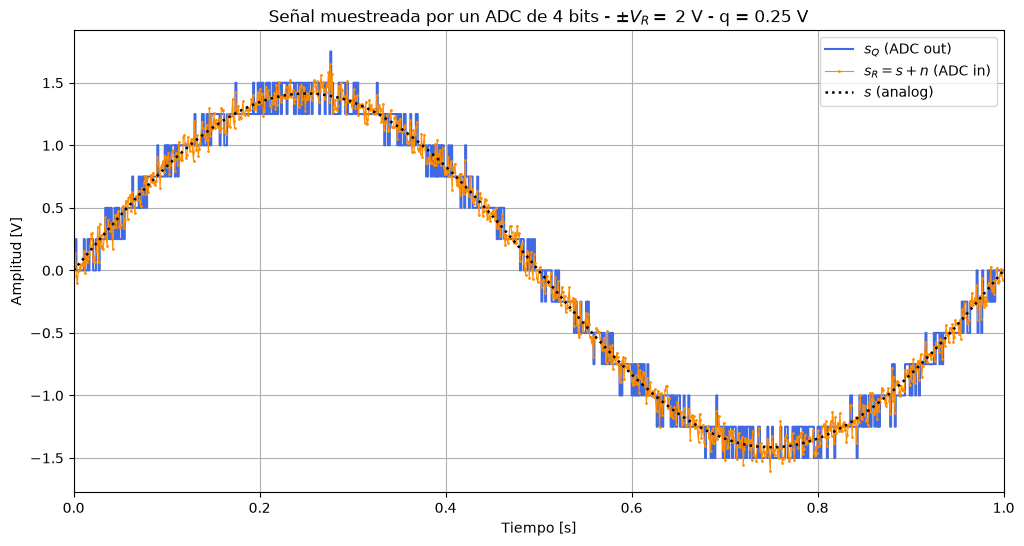

In [3]:
plt.figure(figsize=(12, 6))

plt.step(tt, xx_q, where='post', color='royalblue', linewidth=1.5, label=r'$s_Q$ (ADC out)')
plt.plot(tt, senal_final, color='darkorange', marker='.', markersize=2, linewidth=0.8, label=r'$s_R=s+n$ (ADC in)')
plt.plot(tt, xx, color='black', linestyle=':', linewidth=1.8, label=r'$s$ (analog)')

plt.title(r'Señal muestreada por un ADC de ' + str(B) + r' bits - $\pm V_R=$ ' + str(Vr) + ' V - q = ' + str(round(qq, 3)) + ' V')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')

plt.xlim(0, 1)
plt.grid()
plt.legend()
plt.show()

### Representación frecuencial

Se calcula la FFT de la salida del ADC, del ruido analógico y del ruido de cuantización. A partir del módulo al cuadrado se obtiene su representación en potencia, expresada en dB.

Además, se indican los valores medios de los pisos de ruido analógico y de cuantización para facilitar su comparación.

In [4]:
# FFT
xx_q_k = (1/N)*np.fft.fft(xx_q)
ruido_analogico_k = (1/N)*np.fft.fft(ruido_analogico)
nq_k = (1/N)*np.fft.fft(nq)

# Potencia espectral unilateral
pot_xx_q = 2*(np.abs(xx_q_k[0:N//2])**2)
pot_ruido_analogico = 2*(np.abs(ruido_analogico_k[0:N//2])**2)
pot_nq = 2*(np.abs(nq_k[0:N//2])**2)

# Pasaje a dB
pot_xx_q_db = 10*np.log10(pot_xx_q)
pot_ruido_analogico_db = 10*np.log10(pot_ruido_analogico)
pot_nq_db = 10*np.log10(pot_nq)

# Valores medios de los pisos de ruido
piso_analogico_db = 10*np.log10(np.mean(pot_ruido_analogico[1:]))
piso_nq_db = 10*np.log10(np.mean(pot_nq))

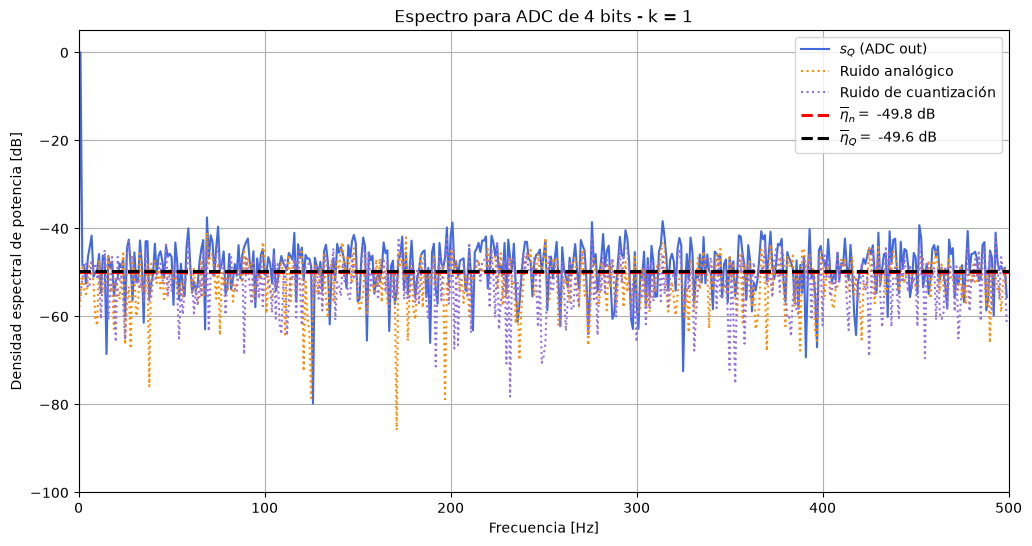

In [5]:
plt.figure(figsize=(12, 6))

# Espectros
plt.plot(bins, pot_xx_q_db, color='royalblue', linewidth=1.5, label=r'$s_Q$ (ADC out)')
plt.plot(bins, pot_ruido_analogico_db, color='darkorange', linestyle=':', linewidth=1.5, label='Ruido analógico')
plt.plot(bins, pot_nq_db, color='mediumpurple', linestyle=':', linewidth=1.5, label='Ruido de cuantización')

# Pisos medios
plt.axhline(piso_analogico_db, color='red', linestyle='--', linewidth=2.2, label=r'$\overline{\eta}_n=$ ' + str(round(piso_analogico_db, 1)) + ' dB')
plt.axhline(piso_nq_db, color='black', linestyle='--', linewidth=2.2, label=r'$\overline{\eta}_Q=$ ' + str(round(piso_nq_db, 1)) + ' dB')

plt.title('Espectro para ADC de ' + str(B) + ' bits - k = ' + str(k))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia [dB]')

plt.xlim(0, fs/2)
plt.ylim(-100, 5)

plt.grid()
plt.legend()
plt.show()

### Análisis de los resultados

Observando las representaciones temporal y espectral se pudo corroborar el comportamiento esperado para $k_n=1$, donde se establece que $P_n=P_q$.

En el dominio temporal se observa que la salida del ADC adopta niveles discretos de amplitud, evidenciando el efecto de la cuantización sobre la señal de entrada. A su vez, puede distinguirse la perturbación introducida previamente por el ruido analógico.

En el dominio frecuencial se observa que el ruido analógico y el ruido de cuantización presentan niveles de potencia aproximadamente iguales, en concordancia con la condición impuesta $P_n=P_q$. Para facilitar esta comparación se representó también el valor medio de la potencia espectral de cada ruido, denominado **piso de ruido**. Ambos pisos resultaron próximos entre sí, permitiendo verificar de forma más clara el comportamiento esperado para $k_n=1$. Las pequeñas diferencias observadas se atribuyen a la naturaleza aleatoria de las señales de ruido y a la cantidad finita de muestras utilizadas.

### Distribución del ruido de cuantización

Finalmente, se representa el histograma de $n_q[n]$ para observar si los valores del error se distribuyen aproximadamente de manera uniforme dentro del intervalo $[-q/2,q/2]$. La línea punteada representa cualitativamente la distribución uniforme ideal.

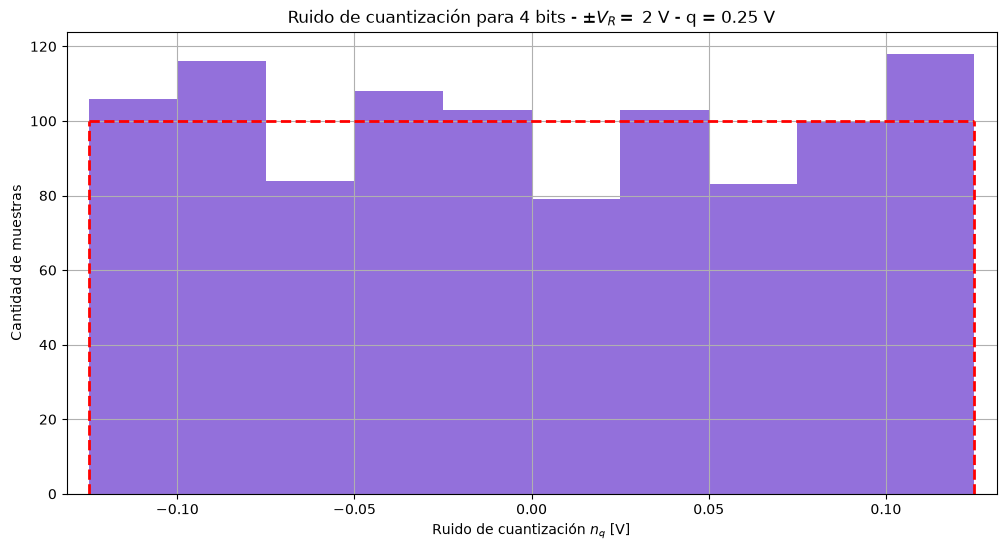

In [6]:
cantidad_bins = 10

plt.figure(figsize=(12, 6))

plt.hist(nq, bins=cantidad_bins, range=(-qq/2, qq/2), color='mediumpurple')

# Distribución uniforme ideal
altura_uniforme = N/cantidad_bins

plt.hlines(altura_uniforme, -qq/2, qq/2, color='red', linestyle='--', linewidth=2)
plt.vlines([-qq/2, qq/2], 0, altura_uniforme, color='red', linestyle='--', linewidth=2)

plt.title(r'Ruido de cuantización para ' + str(B) + r' bits - $\pm V_R=$ ' + str(Vr) + ' V - q = ' + str(round(qq, 3)) + ' V')
plt.xlabel(r'Ruido de cuantización $n_q$ [V]')
plt.ylabel('Cantidad de muestras')

plt.xlim(-qq/2*1.05, qq/2*1.05)
plt.grid()
plt.show()

### Test de uniformidad

Además de la inspección visual del histograma, se aplica un test de Kolmogorov-Smirnov para evaluar si el ruido de cuantización es compatible con una distribución uniforme en $[-q/2,q/2]$.

Se plantea:

- $H_0$: las muestras son compatibles con una distribución uniforme.
- $H_1$: las muestras no son compatibles con una distribución uniforme.

Se adopta un nivel de significancia de $\alpha=0.05$. Si $p<\alpha$, se rechaza $H_0$; en caso contrario, no existe evidencia suficiente para rechazarla.

In [7]:
# Test de Kolmogorov-Smirnov para distribución uniforme

from scipy import stats

alpha = 0.05

# H0: el ruido de cuantización es compatible con una distribución uniforme
# H1: el ruido de cuantización no es compatible con una distribución uniforme

D, p_value = stats.kstest(nq, 'uniform', args=(-qq/2, qq), alternative='two-sided')

print("Estadístico D =", round(D, 4))
print("p-value =", round(p_value, 4))

if p_value < alpha:
    print("=" * 45)
    print("Se rechaza H0: las muestras no son compatibles con una distribución uniforme.")
    print("=" * 45)
else:
    print("=" * 45)
    print("No se rechaza H0: las muestras son compatibles con una distribución uniforme.")
    print("=" * 45)

Estadístico D = 0.0234
p-value = 0.6343
No se rechaza H0: las muestras son compatibles con una distribución uniforme.


### Análisis de la distribución del ruido de cuantización

El histograma del ruido de cuantización presenta una distribución aproximadamente uniforme dentro del intervalo $[-q/2,q/2]$, como predice el modelo teórico del cuantizador.

Este resultado se complementó con el test de Kolmogorov-Smirnov. Como el $p$-value obtenido fue mayor que el nivel de significancia $\alpha=0.05$, no se rechazó la hipótesis nula. Por lo tanto, los resultados obtenidos son compatibles con la hipótesis de que el ruido de cuantización sigue aproximadamente una distribución uniforme.

## b) Comparación para distintos valores de $B$ y $k_n$

Se analizarán las combinaciones de $B=\{4,8,16\}$ bits y $k_n=\{0.1,1,10\}$, manteniendo el mismo rango analógico y frecuencia de muestreo.

La comparación se realizará en el dominio temporal y frecuencial. Además, se estudiará particularmente el efecto de $k_n$ sobre el ruido de cuantización mediante su secuencia temporal, autocorrelación y espectro.

In [8]:
valores_B = [4, 8, 16]
valores_k = [0.1, 1, 10]

### Comparación temporal para $B=4$

Para estudiar el efecto de variar $k_n$ en el dominio temporal se selecciona $B=4$, ya que su paso de cuantización permite distinguir claramente los niveles discretos de salida.

Al aumentar la cantidad de bits disminuyen tanto el paso de cuantización como la potencia del ruido analógico debido a que $P_n=k_nP_q$. Para $B=8$ y especialmente para $B=16$, las señales de entrada y salida quedan prácticamente superpuestas en la escala temporal utilizada, por lo que su comparación no aporta información relevante.Es por esto que el efecto de aumentar la cantidad de bits se analizará posteriormente en el dominio frecuencial.

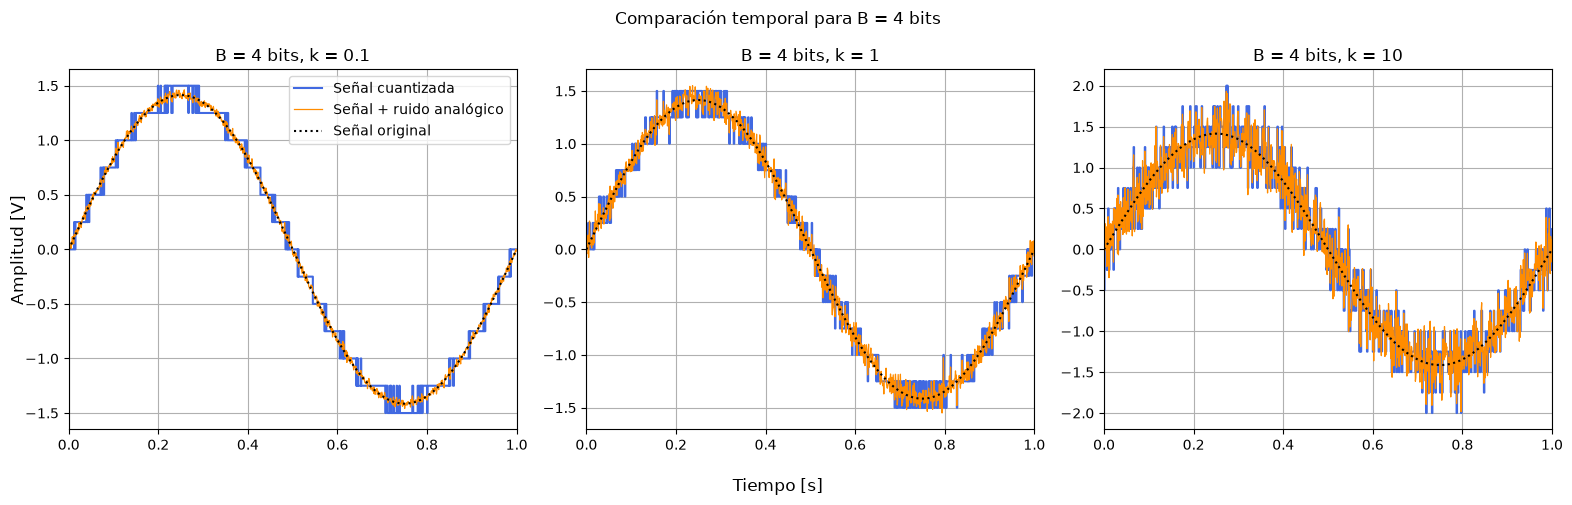

In [9]:
B_temp = 4
qq_temp = vfs/(2**B_temp)
Pq_temp = qq_temp**2/12

# Para graficar: crea 3 gráficos en una misma fila
fig_temporal, ax_temporal = plt.subplots(1, 3, figsize=(16, 5))

for col in range(len(valores_k)):

    k_b = valores_k[col]

    Pn_b = k_b*Pq_temp
    desv_est_b = np.sqrt(Pn_b)

    ruido_analogico_b = np.random.normal(mu, desv_est_b, N)
    senal_final_b = xx + ruido_analogico_b

    xx_q_b = np.round(senal_final_b/qq_temp)*qq_temp

    # Para graficar: col indica en cuál de los 3 gráficos dibujar
    ax_temporal[col].step(tt, xx_q_b, where='post', color='royalblue', linewidth=1.5, label='Señal cuantizada')
    ax_temporal[col].plot(tt, senal_final_b, color='darkorange', linewidth=0.9, label='Señal + ruido analógico')
    ax_temporal[col].plot(tt, xx, color='black', linestyle=':', linewidth=1.5, label='Señal original')

    ax_temporal[col].set_title('B = 4 bits, k = ' + str(k_b))
    ax_temporal[col].set_xlim(0, 1)
    ax_temporal[col].grid()

# Para graficar
fig_temporal.suptitle('Comparación temporal para B = 4 bits')
fig_temporal.supxlabel('Tiempo [s]')
fig_temporal.supylabel('Amplitud [V]')
ax_temporal[0].legend()
fig_temporal.tight_layout()
plt.show()

### Análisis temporal

Al mantener fija la resolución del ADC en $B=4$ bits y variar únicamente el factor $k_n$, el paso de cuantización $q$ y la potencia de ruido de cuantización $P_q$ permanecen constantes. Por lo tanto, lo que cambia entre los distintos casos es la potencia del ruido analógico, determinada por $P_n=k_nP_q$.

Para $k_n=0.1$, la potencia del ruido analógico es diez veces menor que la potencia del ruido de cuantización. En este caso, la señal llega al ADC con una perturbación relativamente chica y el efecto de la cuantización resulta más importante. Esto representa una situación en la que la etapa analógica entrega una señal de mejor calidad que la que el ADC puede aprovechar con esa resolución.

Para $k_n=1$, ambas potencias de ruido son comparables. Esta es la situación más equilibrada desde el punto de vista del diseño, ya que la calidad de la señal proveniente de la etapa analógica y la resolución del ADC se encuentran aproximadamente en el mismo nivel.

Para $k_n=10$, la potencia del ruido analógico es diez veces mayor que la potencia del ruido de cuantización, por lo que la perturbación sobre la señal de entrada se vuelve mucho más evidente. En este caso, el ADC tiene una resolución mayor que la calidad efectiva de la señal que recibe: puede representar variaciones muy pequeñas, pero parte de esas variaciones corresponden al ruido que ya estaba presente antes de la conversión. En otras palabras, parte de la capacidad de resolución del ADC termina utilizándose para representar ruido y no información útil de la señal.

### Comparación espectral

Para estudiar conjuntamente el efecto de la cantidad de bits y del nivel de ruido analógico se representan las nueve configuraciones en frecuencia.

Cada fila corresponde a un valor de $B$ y cada columna a un valor de $k_n$. De esta forma se puede comparar horizontalmente el efecto de variar la potencia del ruido analógico y verticalmente el efecto de modificar la resolución del ADC.

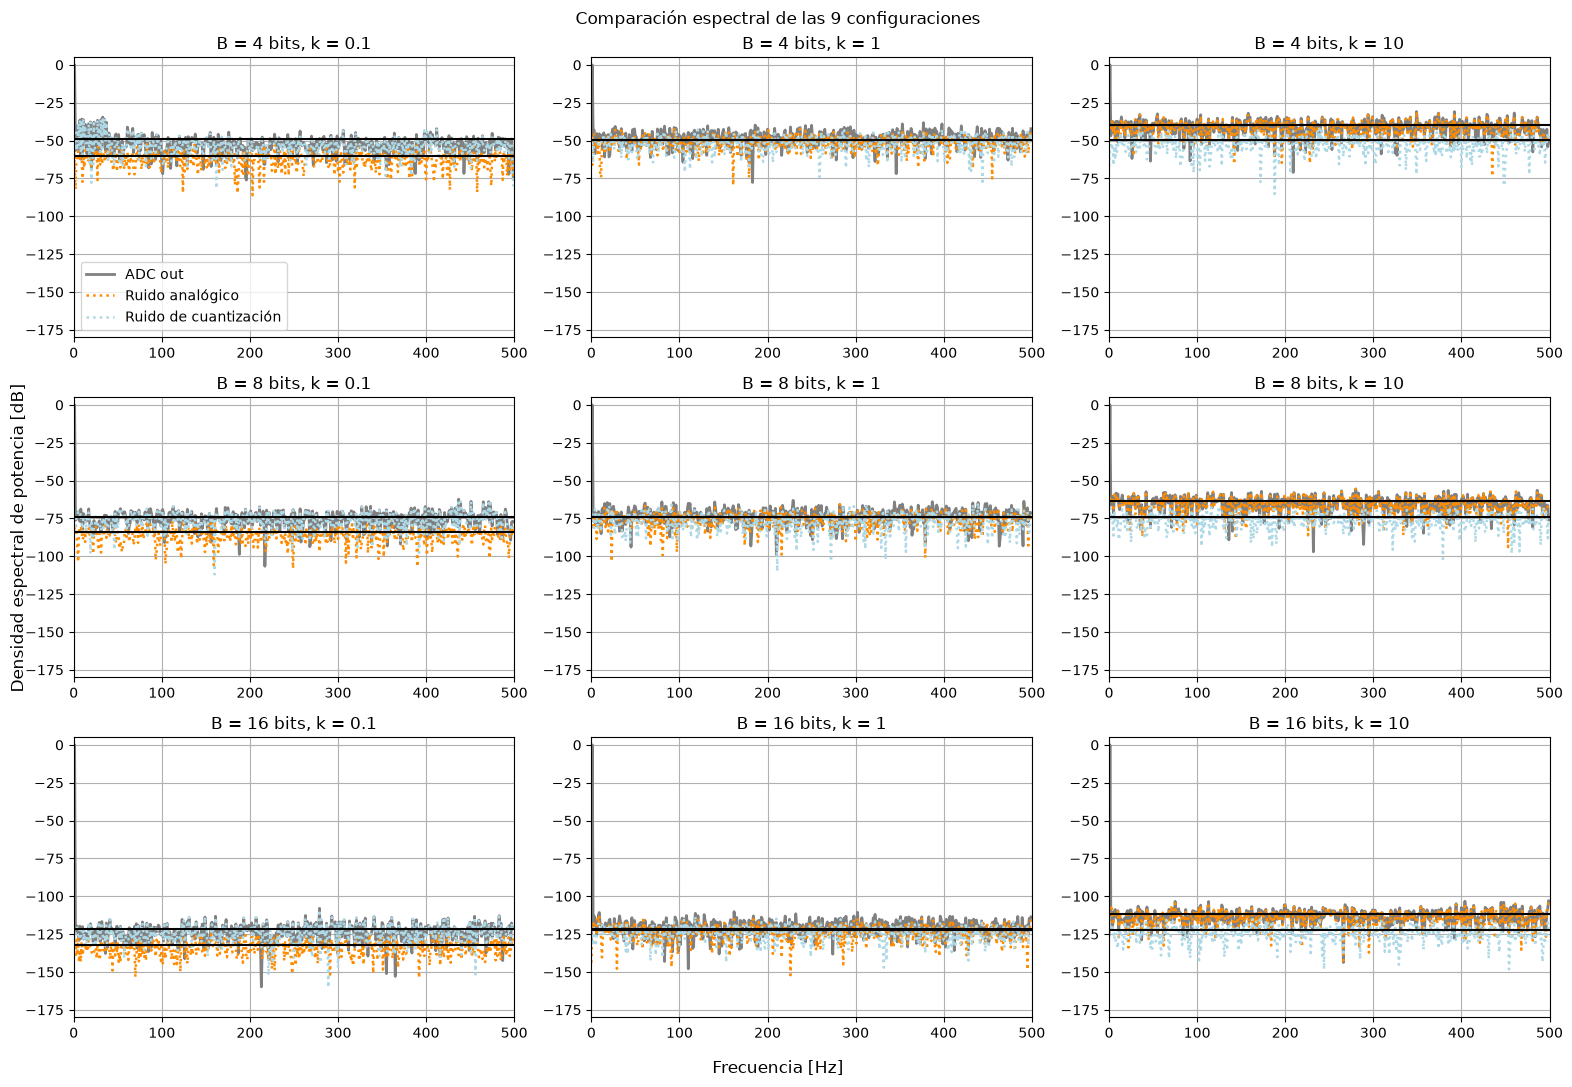

In [10]:
# Para graficar: 3 filas para B y 3 columnas para k
fig_espectral, ax_espectral = plt.subplots(3, 3, figsize=(16, 11))

for fila in range(len(valores_B)):

    B_b = valores_B[fila]

    qq_b = vfs/(2**B_b)
    Pq_b = qq_b**2/12

    for col in range(len(valores_k)):

        k_b = valores_k[col]

        Pn_b = k_b*Pq_b
        desv_est_b = np.sqrt(Pn_b)

        ruido_analogico_b = np.random.normal(mu, desv_est_b, N)
        senal_final_b = xx + ruido_analogico_b

        xx_q_b = np.round(senal_final_b/qq_b)*qq_b
        nq_b = xx_q_b - senal_final_b

        # FFT
        xx_q_k_b = (1/N)*np.fft.fft(xx_q_b)
        ruido_analogico_k_b = (1/N)*np.fft.fft(ruido_analogico_b)
        nq_k_b = (1/N)*np.fft.fft(nq_b)

        # Potencias espectrales
        pot_xx_q_b = 2*(np.abs(xx_q_k_b[0:N//2])**2)
        pot_ruido_analogico_b = 2*(np.abs(ruido_analogico_k_b[0:N//2])**2)
        pot_nq_b = 2*(np.abs(nq_k_b[0:N//2])**2)

        # Paso a dB
        pot_xx_q_db_b = 10*np.log10(pot_xx_q_b + 1e-20)
        pot_ruido_analogico_db_b = 10*np.log10(pot_ruido_analogico_b + 1e-20)
        pot_nq_db_b = 10*np.log10(pot_nq_b + 1e-20)

        # Pisos medios
        piso_analogico_db_b = 10*np.log10(np.mean(pot_ruido_analogico_b[1:]))
        piso_nq_db_b = 10*np.log10(np.mean(pot_nq_b[1:]))

        # Para graficar
        ax_espectral[fila, col].plot(bins, pot_xx_q_db_b, color='gray', linewidth=2.0, label='ADC out')
        ax_espectral[fila, col].plot(bins, pot_ruido_analogico_db_b, color='darkorange', linestyle=':', linewidth=1.8, label='Ruido analógico')
        ax_espectral[fila, col].plot(bins, pot_nq_db_b, color='lightblue', linestyle=':', linewidth=1.8, label='Ruido de cuantización')

        ax_espectral[fila, col].axhline(piso_analogico_db_b, color='black', linestyle='-', linewidth=1.5)
        ax_espectral[fila, col].axhline(piso_nq_db_b, color='black', linestyle='-', linewidth=1.5)

        ax_espectral[fila, col].set_title('B = ' + str(B_b) + ' bits, k = ' + str(k_b))
        ax_espectral[fila, col].set_xlim(0, 500)
        ax_espectral[fila, col].set_ylim(-180, 5)
        ax_espectral[fila, col].grid()

# Para graficar
fig_espectral.suptitle('Comparación espectral de las 9 configuraciones')
fig_espectral.supxlabel('Frecuencia [Hz]')
fig_espectral.supylabel('Densidad espectral de potencia [dB]')
ax_espectral[0, 0].legend()
fig_espectral.tight_layout()
plt.show()

### Análisis espectral

Al recorrer cada fila, manteniendo fija la resolución, se observa que el factor $k_n$ modifica la relación entre los pisos de ruido analógico y de cuantización. Para $k_n=0.1$, el piso analógico se encuentra aproximadamente $10\,\text{dB}$ por debajo del piso de cuantización, por lo que prevalece el ruido introducido por la conversión. Para $k_n=1$, ambos pisos presentan niveles similares, mientras que para $k_n=10$ el piso analógico se encuentra aproximadamente $10\,\text{dB}$ por encima y pasa a ser la principal limitación.

Al recorrer las columnas verticalmente se observa que, al aumentar la cantidad de bits, disminuyen ambos pisos de ruido. Esto ocurre porque un mayor número de bits reduce el paso de cuantización $q$ y, en consecuencia, la potencia $P_q=q^2/12$. Además, como en esta simulación se impone $P_n=k_nP_q$, la potencia del ruido analógico disminuye en la misma proporción para un mismo valor de $k_n$.

Los resultados muestran también que la cantidad de bits por sí sola no determina la calidad del sistema. Incluso para un ADC de 16 bits pueden presentarse situaciones de desajuste entre la etapa analógica y la digital. Si $k_n=10$, la resolución del ADC es superior a la calidad de la señal que recibe y parte de esa capacidad termina representando variaciones debidas al ruido analógico. En cambio, para $k_n=0.1$ la etapa analógica posee una calidad superior a la que puede aprovechar el conversor. El caso $k_n=1$ representa la situación de diseño más equilibrada.

### Análisis adicional: correlación del ruido de cuantización

Como análisis complementario, se estudiará con mayor detalle el comportamiento del ruido de cuantización para los distintos valores de $k_n$. En particular, se analizará su secuencia temporal, su autocorrelación y su espectro, con el objetivo de observar cuándo el error de cuantización presenta patrones determinísticos y cuándo puede aproximarse mejor a un ruido incorrelado y de espectro aproximadamente plano.

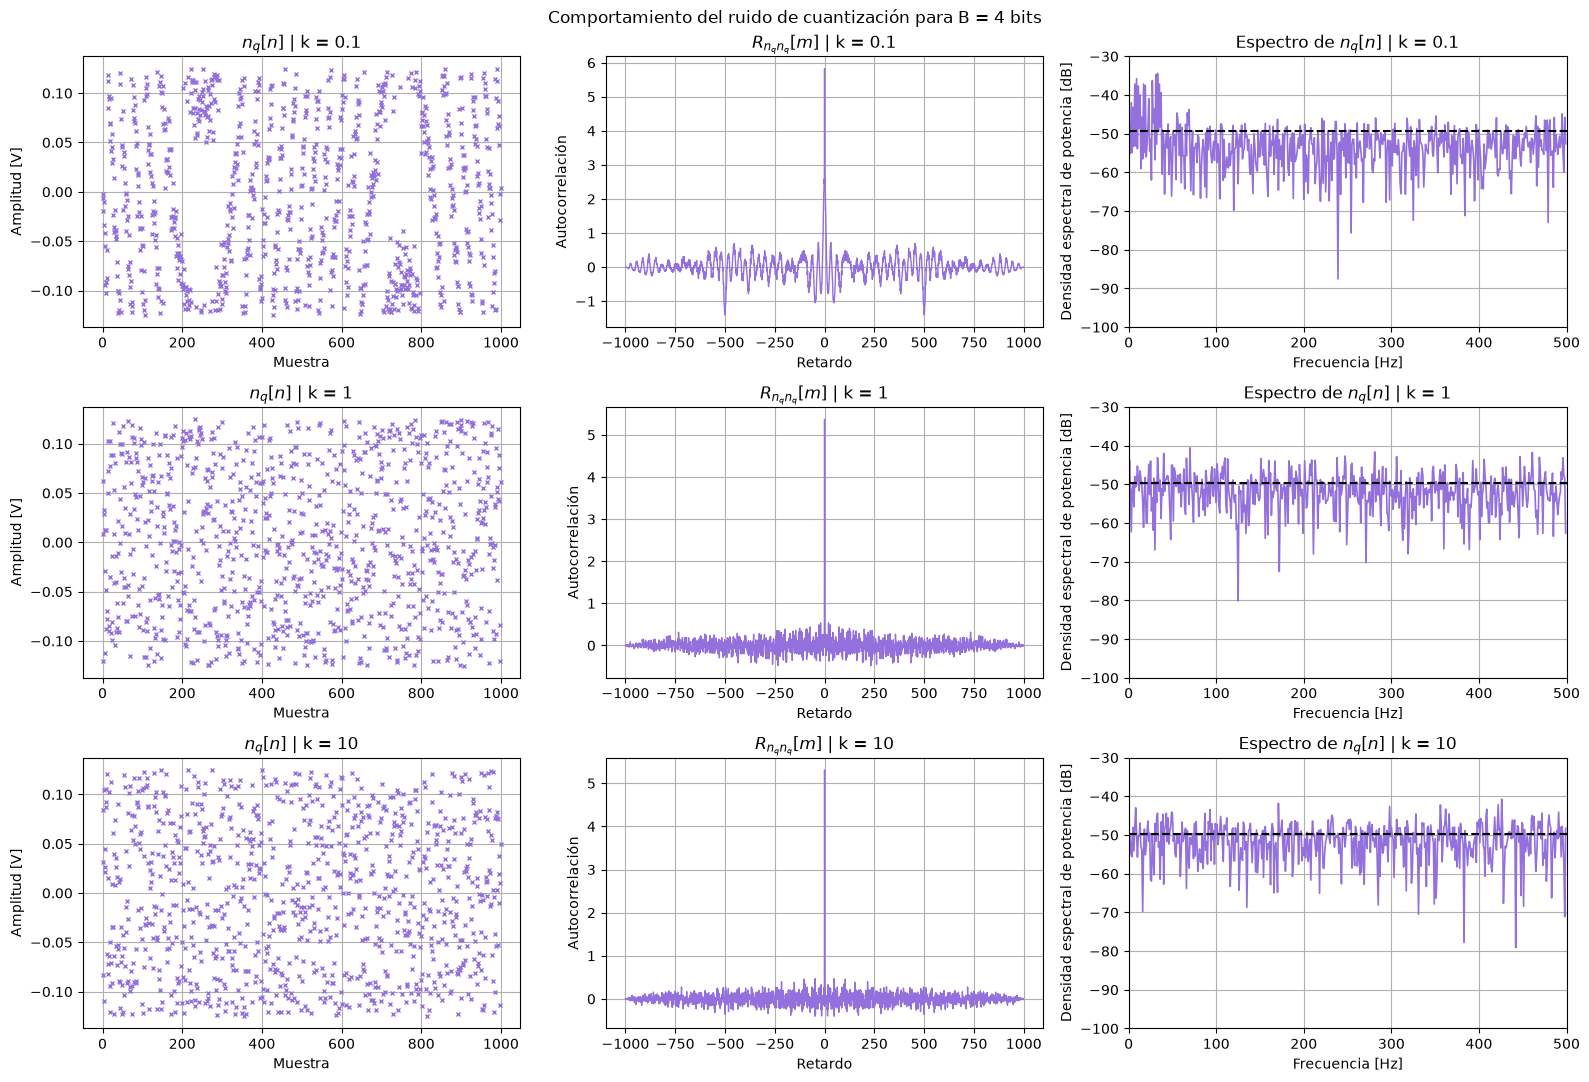

In [11]:
B_corr = 4
qq_corr = vfs/(2**B_corr)
Pq_corr = qq_corr**2/12

# Retardos de la autocorrelación: para N=1000 van de -999 a +999
lags = np.arange(-(N-1), N)

# Para graficar: filas = k; columnas = secuencia, autocorrelación y espectro
fig_corr, ax_corr = plt.subplots(3, 3, figsize=(16, 11))

for fila in range(len(valores_k)):

    k_b = valores_k[fila]

    Pn_b = k_b*Pq_corr
    desv_est_b = np.sqrt(Pn_b)

    ruido_analogico_b = np.random.normal(mu, desv_est_b, N)
    senal_final_b = xx + ruido_analogico_b

    xx_q_b = np.round(senal_final_b/qq_corr)*qq_corr
    nq_b = xx_q_b - senal_final_b

    # Autocorrelación para todos los retardos posibles
    correlacion_nq_b = np.correlate(nq_b, nq_b, "full")

    # Espectro del ruido de cuantización
    nq_k_b = (1/N)*np.fft.fft(nq_b)
    pot_nq_b = 2*(np.abs(nq_k_b[0:N//2])**2)
    pot_nq_db_b = 10*np.log10(pot_nq_b)

    # Piso medio; [1:] deja afuera solamente la componente DC
    piso_nq_db_b = 10*np.log10(np.mean(pot_nq_b[1:]))

    # Para graficar: secuencia sin unir las muestras
    ax_corr[fila, 0].plot(nq_b, marker='x', linestyle='None', color='mediumpurple', markersize=3)
    ax_corr[fila, 0].set_title(r'$n_q[n]$ | k = ' + str(k_b))
    ax_corr[fila, 0].set_xlabel('Muestra')
    ax_corr[fila, 0].set_ylabel('Amplitud [V]')
    ax_corr[fila, 0].grid()

    # Para graficar: autocorrelación
    ax_corr[fila, 1].plot(lags, correlacion_nq_b, color='mediumpurple', linewidth=1)
    ax_corr[fila, 1].set_title(r'$R_{n_qn_q}[m]$ | k = ' + str(k_b))
    ax_corr[fila, 1].set_xlabel('Retardo')
    ax_corr[fila, 1].set_ylabel('Autocorrelación')
    ax_corr[fila, 1].grid()

    # Para graficar: espectro y piso medio
    ax_corr[fila, 2].plot(bins, pot_nq_db_b, color='mediumpurple', linewidth=1.2)
    ax_corr[fila, 2].axhline(piso_nq_db_b, color='black', linestyle='--', linewidth=1.5)
    ax_corr[fila, 2].set_title(r'Espectro de $n_q[n]$ | k = ' + str(k_b))
    ax_corr[fila, 2].set_xlabel('Frecuencia [Hz]')
    ax_corr[fila, 2].set_ylabel('Densidad espectral de potencia [dB]')
    ax_corr[fila, 2].set_xlim(0, 500)
    ax_corr[fila, 2].set_ylim(-100, -30)
    ax_corr[fila, 2].grid()

# Para graficar
fig_corr.suptitle('Comportamiento del ruido de cuantización para B = 4 bits')
fig_corr.tight_layout()
plt.show()

### Análisis de correlación del ruido de cuantización

El objetivo de esta representación es analizar bajo qué condiciones el ruido de cuantización puede aproximarse al modelo habitualmente utilizado de ruido blanco e incorrelado. Para ello, en cada fila se representa, para un mismo valor de $k_n$, la secuencia temporal del ruido de cuantización $n_q[n]$, su autocorrelación y su espectro.

En la columna correspondiente a la autocorrelación, el eje horizontal representa el *lag* o retardo, es decir, cuántas muestras se desplaza la secuencia respecto de sí misma al compararla. Para un retardo nulo cada muestra se compara consigo misma, por lo que siempre aparece un máximo en $m=0$. En cambio, la aparición de valores elevados o picos para retardos distintos de cero indica que existen muestras separadas cierta cantidad de posiciones que mantienen algún grado de relación temporal.

Esto se observa especialmente para $k_n=0.1$. En la secuencia temporal pueden distinguirse agrupamientos y cierto ordenamiento entre las muestras, mientras que en su autocorrelación aparecen picos y oscilaciones apreciables además del máximo central. La presencia de estos picos indica que el error de cuantización conserva estructura temporal y, por lo tanto, no puede considerarse completamente incorrelado.

Este comportamiento puede entenderse a partir de la señal que ingresa al cuantizador. La senoidal original es una señal determinística, mientras que el ruido analógico constituye la componente estocástica o aleatoria. Para $k_n=0.1$, la potencia de ruido analógico es relativamente chica, por lo que la entrada al ADC conserva en gran medida el recorrido ordenado de la senoidal.

Como la cuantización se realiza mediante un proceso no lineal de redondeo, el error de cuantización surge como consecuencia de la forma en que la señal atraviesa los distintos niveles y umbrales de decisión del cuantizador. Cuando la componente aleatoria es pequeña, esos cruces ocurren de manera relativamente predecible y el error también presenta un cierto ordenamiento temporal. En cambio, cuando el ruido analógico adquiere una magnitud suficiente para perturbar las muestras cerca de los umbrales de decisión (ubicados a una distancia $q/2$ de cada nivel de cuantización), una pequeña variación puede hacer que una muestra sea redondeada hacia uno u otro nivel. Esto rompe progresivamente el patrón determinístico del error de cuantización.

Al aumentar $k_n$ a $1$ y luego a $10$, este efecto puede observarse en las tres representaciones. La secuencia temporal de $n_q[n]$ se vuelve visualmente más desordenada, mientras que la autocorrelación queda cada vez más dominada por el máximo correspondiente a $m=0$ y presenta valores relativamente menores para otros retardos. En particular, para $k_n=10$ ya no se distingue a simple vista un patrón temporal claro.

Sin embargo, la ausencia de un patrón visible en la secuencia temporal no permite asegurar por sí sola que el ruido sea incorrelado. La observación de un ordenamiento claro constituye una evidencia fuerte de correlación, como ocurre para $k_n=0.1$, pero no observarlo solamente constituye un indicio. Por este motivo resulta necesario complementar la inspección temporal con la autocorrelación y con el análisis espectral.

La relación entre estas dos últimas representaciones se explica porque la densidad espectral de potencia está relacionada con la transformada de Fourier de la autocorrelación. Para un ruido idealmente incorrelado, la autocorrelación se aproxima a una delta centrada en $m=0$. Como la transformada de Fourier de una delta es una constante, resulta razonable esperar que, cuanto más se aproxime la autocorrelación a una delta, más plano sea el espectro de potencia.

Esto también se verifica en las figuras. Para $k_n=0.1$, la autocorrelación presenta una estructura importante fuera del retardo nulo y, en correspondencia, el espectro muestra zonas de mayor y menor potencia, es decir, un cierto coloreo espectral. Al aumentar $k_n$, la autocorrelación se vuelve más semejante a una delta y el espectro se vuelve progresivamente más plano, aproximándose al comportamiento esperado para un ruido blanco.

Por lo tanto, los resultados muestran que el ruido de cuantización no es necesariamente blanco e incorrelado para cualquier señal de entrada. Estas propiedades dependen de las condiciones bajo las cuales funciona el cuantizador. Cuando la componente aleatoria de entrada es pequeña, el proceso no lineal de redondeo puede producir un error fuertemente estructurado; cuando el ruido analógico adquiere una magnitud comparable con la escala de cuantización, ese ordenamiento comienza a romperse y el error puede aproximarse mejor al modelo de ruido blanco e incorrelado.

## Bonus: relación entre cantidad de bits y SNR

Holton relaciona la cantidad de bits de un ADC con el SNR debido al ruido de cuantización mediante:

$SNR = 6.02B + 10.79 + 20\log_{10}\left(\frac{\sigma_s}{V_{FS}}\right)$ donde $B$ es la cantidad de bits, $\sigma_s$ es el valor RMS de la señal y $V_{FS}$ es el rango total del conversor.

Para el caso particular de una senoidal que utiliza completamente el rango del ADC, Holton obtiene: $SNR \approx 6.02B + 1.76\ \text{dB}$

De esta expresión se obtiene la relación principal buscada: por cada bit adicional, el SNR aumenta aproximadamente $6.02\,\text{dB}$. Esto también puede interpretarse a partir del paso de cuantización: al agregar un bit, $q$ se reduce a la mitad y, como $P_q=q^2/12$, la potencia del ruido de cuantización se reduce a la cuarta parte. Por lo tanto, el aumento de SNR es $10\log_{10}(4)\approx6.02\,\text{dB}$ por bit.

En este trabajo la senoidal no utiliza completamente el rango del ADC. El rango total es $V_{FS}=4\,V$, ya que el conversor trabaja entre $-2\,V$ y $+2\,V$. Además, la señal tiene amplitud $\sqrt{2}\,V$, por lo que su valor RMS es $\sigma_s=1\,V$.

Reemplazando estos valores en la expresión general de Holton:

$$SNR = 6.02B + 10.79 + 20\log_{10}\left(\frac{1}{4}\right)$ y como $20\log_{10}(1/4)\approx-12.04\,\text{dB}$$:

$$SNR \approx 6.02B - 1.25\,\text{dB}$$

La diferencia respecto de la expresión $6.02B+1.76\,\text{dB}$ se debe a que nuestra senoidal no alcanza la amplitud máxima disponible del ADC. Sin embargo, la relación con la cantidad de bits no cambia: el SNR continúa aumentando aproximadamente $6.02\,\text{dB}$ por cada bit agregado.

A continuación se calculará el SNR para $B=4$, $8$ y $16$ bits utilizando los parámetros de nuestra simulación, para verificar numéricamente esta relación.

In [12]:
Ps = np.mean(xx**2)

print("Potencia de la señal =", Ps,"W")
print("=" * 45)
for i in range(len(valores_B)):

    B_b = valores_B[i]

    qq_b = vfs/(2**B_b)
    Pq_b = qq_b**2/12

    SNR_q_b = 10*np.log10(Ps/Pq_b)

    print("B =", B_b, "bits -> SNR de cuantización =", round(SNR_q_b, 2), "dB")
print("=" * 45)

Potencia de la señal = 1.0000000000000002 W
B = 4 bits -> SNR de cuantización = 22.83 dB
B = 8 bits -> SNR de cuantización = 46.92 dB
B = 16 bits -> SNR de cuantización = 95.08 dB


Se puede observar que los valores obtenidos verifican lo esperado por la relación anterior. Por ejemplo, al pasar de $4$ a $8$ bits el SNR aumenta de $22.83\,\text{dB}$ a $46.92\,\text{dB}$, por lo que:

$$\frac{46.92-22.83}{8-4}\approx6.02\,\text{dB/bit}$$

Esto coincide con el incremento aproximado de $6\,\text{dB}$ de SNR por cada bit adicional.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Conclusiones</h2>
</div>


A lo largo de la simulación se pudo observar cómo la calidad de la conversión no depende únicamente de la cantidad de bits del ADC, sino también de la relación entre el ruido analógico presente a su entrada y el ruido introducido por la cuantización. El factor $k_n=P_n/P_q$ permitió representar distintas situaciones de diseño: para $k_n=0.1$ predomina el ruido de cuantización, para $k_n=10$ predomina el ruido analógico y para $k_n=1$ ambas potencias resultan comparables, representando una situación de diseño más equilibrada. Esto muestra que aumentar la resolución del ADC no garantiza por sí solo una mejora en la calidad del sistema, ya que parte de esa resolución puede terminar utilizándose para representar variaciones debidas al ruido analógico.

También se verificó que, al aumentar la cantidad de bits, disminuye el paso de cuantización y con él la potencia del ruido de cuantización. En esta simulación, debido a que $P_n=k_nP_q$, el piso de ruido analógico también disminuye al aumentar $B$, manteniéndose para cada $k_n$ la misma relación relativa entre ambos pisos. De esta forma, los gráficos espectrales permitieron visualizar tanto el efecto de la resolución como las diferencias de aproximadamente $10\,\text{dB}$ entre los pisos para $k_n=0.1$ y $k_n=10$.

Finalmente, el análisis temporal, la autocorrelación y el espectro del ruido de cuantización permitieron comprobar que su modelado como ruido uniforme, blanco e incorrelado no es válido automáticamente para cualquier señal de entrada. Cuando la componente aleatoria de entrada es pequeña, el proceso no lineal de redondeo puede generar un error con un marcado ordenamiento temporal, una autocorrelación con estructura y un espectro coloreado. Al aumentar el ruido analógico, ese ordenamiento se rompe progresivamente, la autocorrelación se aproxima a una delta y el espectro se vuelve más plano, acercándose al modelo ideal de ruido blanco e incorrelado.

Además de las conclusiones teóricas obtenidas, la resolución de este informe me permitió reforzar y aplicar conceptos trabajados previamente en la materia. En particular, profundice en la interpretación de la autocorrelación y su relación con el espectro, me sirvió vincular herramientas de probabilidad y estadística con el análisis de señales, como el uso de histogramas, distribuciones de probabilidad y pruebas de hipótesis. También adquirí mayor práctica en la interpretación conjunta de representaciones temporales, espectrales y estadísticas, entendiendo cómo cada una aporta información diferente sobre el comportamiento de una señal y de los procesos de ruido.